# CNN Development on Custom Dataset
### CVPR Mid Assignment
**Dataset:** CIFAR-10 (10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)

**Dataset Source:** `torchvision.datasets.CIFAR10` — auto-downloaded, no manual setup needed.

**Notebook Structure:**
1. Import Libraries
2. Load and Explore Dataset
3. Data Preprocessing & Augmentation
4. Define CNN Architecture
5. Training Loop with Validation
6. Evaluate Model on Test Set
7. Visualizations (Loss/Accuracy Curves, Confusion Matrix)
8. Analysis & Discussion of Results
9. Conclusions & Future Work

---
## 1. Import Libraries

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split

# ── Torchvision ───────────────────────────────────────────────────────────────
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

# ── Sklearn (metrics) ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

# ── Torchsummary ─────────────────────────────────────────────────────────────
try:
    from torchsummary import summary
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torchsummary', '-q'])
    from torchsummary import summary

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')

Using device: cpu
PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu


---
## 2. Load and Explore Dataset

**CIFAR-10** contains 60,000 colour images of size **32×32** spread across **10 classes**.
- Training set : 50,000 images
- Test set     : 10,000 images

We further split the training set → 45,000 train / 5,000 validation.

In [2]:
# Class labels
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
NUM_CLASSES = len(CLASS_NAMES)

# ── Minimal transform just for exploration (no augmentation yet) ──────────────
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

# Download dataset
raw_train = CIFAR10(root='./data', train=True,  download=True, transform=basic_transform)
raw_test  = CIFAR10(root='./data', train=False, download=True, transform=basic_transform)

print(f'Total training samples : {len(raw_train)}')
print(f'Total test samples     : {len(raw_test)}')
print(f'Image shape            : {raw_train[0][0].shape}  (C×H×W)')

Total training samples : 50000
Total test samples     : 10000
Image shape            : torch.Size([3, 32, 32])  (C×H×W)


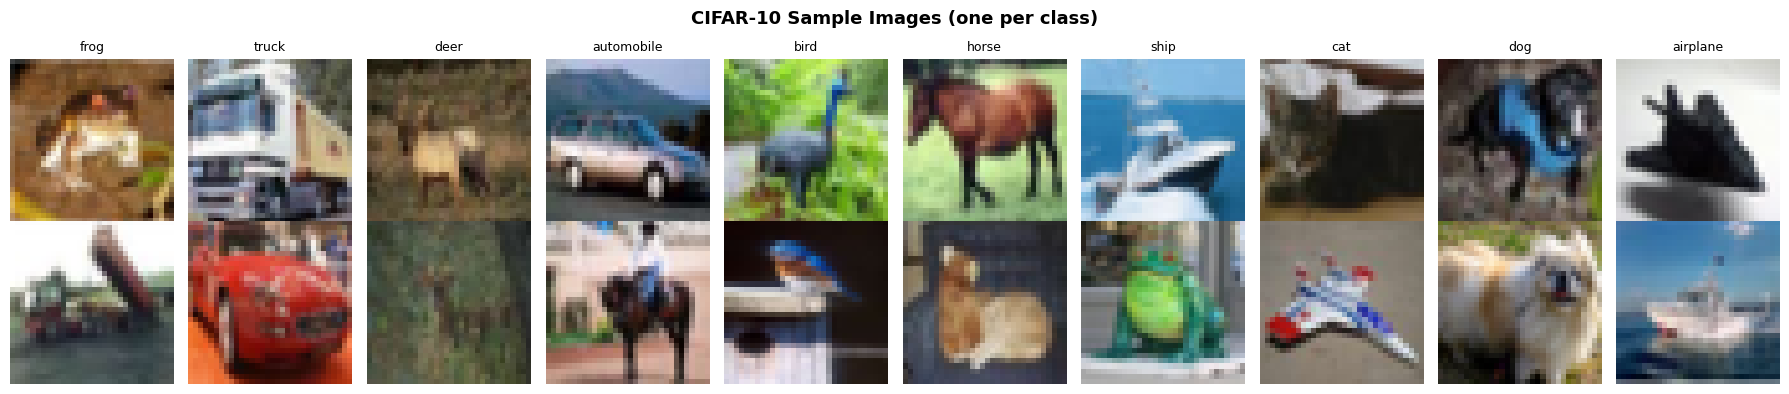

Sample image grid saved.


In [3]:
# ── Visualise sample images ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
shown = {c: False for c in range(NUM_CLASSES)}
row0, row1 = [], []

for img, label in raw_train:
    if not shown[label]:
        shown[label] = True
        row0.append((img, label))
    if all(shown.values()):
        break

# second row: different samples
shown2 = {c: 0 for c in range(NUM_CLASSES)}
for img, label in raw_train:
    shown2[label] += 1
    if shown2[label] == 2:
        row1.append((img, label))
    if all(v >= 2 for v in shown2.values()):
        break

for col, (img, lbl) in enumerate(row0):
    axes[0][col].imshow(img.permute(1,2,0))
    axes[0][col].set_title(CLASS_NAMES[lbl], fontsize=9)
    axes[0][col].axis('off')

for col, (img, lbl) in enumerate(row1):
    axes[1][col].imshow(img.permute(1,2,0))
    axes[1][col].axis('off')

fig.suptitle('CIFAR-10 Sample Images (one per class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120)
plt.show()
print('Sample image grid saved.')

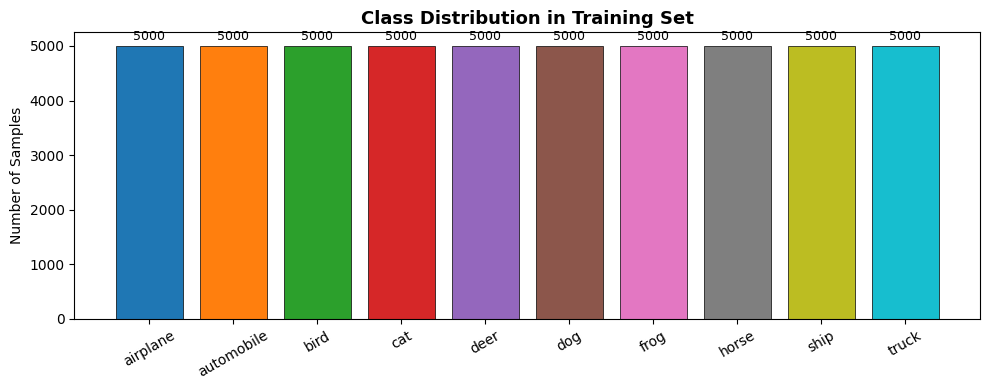

Dataset is balanced — each class has 5000 samples.


In [41]:
# ── Class distribution ────────────────────────────────────────────────────────
labels_all = [label for _, label in raw_train]
counts = np.bincount(labels_all)

plt.figure(figsize=(10, 4))
bars = plt.bar(CLASS_NAMES, counts, color=plt.cm.tab10.colors, edgecolor='black', linewidth=0.5)
plt.title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30)
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(c),
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()
print('Dataset is balanced — each class has', counts[0], 'samples.')

---
## 3. Data Preprocessing & Augmentation

| Split | Size | Augmentation |
|-------|------|--------------|
| Train | 45 000 | RandomCrop, RandomHorizontalFlip, ColorJitter, Normalize |
| Val   |  5 000 | Normalize only |
| Test  | 10 000 | Normalize only |

**Normalization** values are CIFAR-10 channel-wise mean and std computed over the training set:
- mean = (0.4914, 0.4822, 0.4465)
- std  = (0.2023, 0.1994, 0.2010)

In [5]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE   = 64       # mini-batch size; 64 balances speed & memory
NUM_EPOCHS   = 30       # enough to see clear convergence
LR           = 1e-3     # Adam initial learning rate
WEIGHT_DECAY = 1e-4     # L2 regularisation
VAL_SPLIT    = 0.1      # 10 % of train → validation

# ── Normalization constants ────────────────────────────────────────────────────
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),          # random crop with padding
    transforms.RandomHorizontalFlip(p=0.5),        # horizontal flip
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),        # colour jitter
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ── Reload with proper transforms ─────────────────────────────────────────────
full_train = CIFAR10(root='./data', train=True,  download=False, transform=train_transform)
test_ds    = CIFAR10(root='./data', train=False, download=False, transform=val_test_transform)

# Train / val split
val_size   = int(len(full_train) * VAL_SPLIT)
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply val transform to validation split
# (val_ds wraps full_train which uses train_transform; override via Subset trick)
val_ds_clean = CIFAR10(root='./data', train=True, download=False, transform=val_test_transform)
val_ds_clean = torch.utils.data.Subset(val_ds_clean, val_ds.indices)

# ── Data loaders ──────────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds,       batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds_clean,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,        batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}  ({train_size} samples)')
print(f'Val batches   : {len(val_loader)}  ({val_size} samples)')
print(f'Test batches  : {len(test_loader)}  ({len(test_ds)} samples)')

Train batches : 704  (45000 samples)
Val batches   : 79  (5000 samples)
Test batches  : 157  (10000 samples)


---
## 4. Define CNN Architecture

We build **CustomCNN** — a VGG-inspired network with:
- 3 convolutional blocks (each: Conv → BN → ReLU → Conv → BN → ReLU → MaxPool)
- Dropout after each pooling and in the classifier head
- Fully connected classifier with 2 hidden layers

We also define a **version without BN/Dropout** to compare regularisation impact.

In [6]:
class CustomCNN(nn.Module):
    """
    Custom CNN for CIFAR-10 classification.

    Architecture:
      Block 1: Conv(3→32) → BN → ReLU → Conv(32→32) → BN → ReLU → MaxPool → Dropout
      Block 2: Conv(32→64) → BN → ReLU → Conv(64→64) → BN → ReLU → MaxPool → Dropout
      Block 3: Conv(64→128) → BN → ReLU → Conv(128→128) → BN → ReLU → MaxPool → Dropout
      Classifier: FC(128*4*4→512) → BN → ReLU → Dropout → FC(512→256) → ReLU → FC(256→10)

    Parameters
    ----------
    use_bn      : bool  — include Batch Normalisation layers
    dropout_p   : float — dropout probability (0 = no dropout)
    num_classes : int   — output dimension
    """

    def __init__(self, use_bn: bool = True, dropout_p: float = 0.3, num_classes: int = 10):
        super(CustomCNN, self).__init__()
        self.use_bn    = use_bn
        self.dropout_p = dropout_p

        # ── Convolutional Feature Extractor ───────────────────────────────────
        # Block 1  (32×32 → 16×16)
        self.conv1a = nn.Conv2d(3,   32,  kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32,  32,  kernel_size=3, padding=1)
        self.bn1a   = nn.BatchNorm2d(32)
        self.bn1b   = nn.BatchNorm2d(32)
        self.pool1  = nn.MaxPool2d(2, 2)
        self.drop1  = nn.Dropout2d(dropout_p)

        # Block 2  (16×16 → 8×8)
        self.conv2a = nn.Conv2d(32,  64,  kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64,  64,  kernel_size=3, padding=1)
        self.bn2a   = nn.BatchNorm2d(64)
        self.bn2b   = nn.BatchNorm2d(64)
        self.pool2  = nn.MaxPool2d(2, 2)
        self.drop2  = nn.Dropout2d(dropout_p)

        # Block 3  (8×8 → 4×4)
        self.conv3a = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3a   = nn.BatchNorm2d(128)
        self.bn3b   = nn.BatchNorm2d(128)
        self.pool3  = nn.MaxPool2d(2, 2)
        self.drop3  = nn.Dropout2d(dropout_p)

        # ── Classifier ────────────────────────────────────────────────────────
        # After 3 max-pools: 32→16→8→4, so feature map = 128 × 4 × 4 = 2048
        self.fc1     = nn.Linear(128 * 4 * 4, 512)
        self.bn_fc1  = nn.BatchNorm1d(512)
        self.drop_fc = nn.Dropout(dropout_p + 0.1)   # slightly higher in FC
        self.fc2     = nn.Linear(512, 256)
        self.fc3     = nn.Linear(256, num_classes)

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _bn(self, x, bn_layer):
        return bn_layer(x) if self.use_bn else x

    def _drop(self, x, drop_layer):
        return drop_layer(x) if self.dropout_p > 0 else x

    def forward(self, x):
        # Block 1
        x = F.relu(self._bn(self.conv1a(x), self.bn1a))
        x = F.relu(self._bn(self.conv1b(x), self.bn1b))
        x = self._drop(self.pool1(x), self.drop1)

        # Block 2
        x = F.relu(self._bn(self.conv2a(x), self.bn2a))
        x = F.relu(self._bn(self.conv2b(x), self.bn2b))
        x = self._drop(self.pool2(x), self.drop2)

        # Block 3
        x = F.relu(self._bn(self.conv3a(x), self.bn3a))
        x = F.relu(self._bn(self.conv3b(x), self.bn3b))
        x = self._drop(self.pool3(x), self.drop3)

        # Flatten
        x = x.view(x.size(0), -1)          # (B, 2048)

        # Classifier
        x = F.relu(self._bn(self.fc1(x), self.bn_fc1))
        x = self._drop(x, self.drop_fc)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                    # raw logits
        return x


# ── Instantiate both variants ─────────────────────────────────────────────────
model_with_reg    = CustomCNN(use_bn=True,  dropout_p=0.3).to(DEVICE)   # with BN + Dropout
model_without_reg = CustomCNN(use_bn=False, dropout_p=0.0).to(DEVICE)   # plain CNN

print('=== Model WITH Batch Normalisation & Dropout ===')
summary(model_with_reg, input_size=(3, 32, 32))

=== Model WITH Batch Normalisation & Dropout ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
            Conv2d-3           [-1, 32, 32, 32]           9,248
       BatchNorm2d-4           [-1, 32, 32, 32]              64
         MaxPool2d-5           [-1, 32, 16, 16]               0
         Dropout2d-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
       BatchNorm2d-8           [-1, 64, 16, 16]             128
            Conv2d-9           [-1, 64, 16, 16]          36,928
      BatchNorm2d-10           [-1, 64, 16, 16]             128
        MaxPool2d-11             [-1, 64, 8, 8]               0
        Dropout2d-12             [-1, 64, 8, 8]               0
           Conv2d-13            [-1, 128, 8, 8]       

In [7]:
print('=== Model WITHOUT Batch Normalisation & Dropout ===')
summary(model_without_reg, input_size=(3, 32, 32))

=== Model WITHOUT Batch Normalisation & Dropout ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
            Conv2d-2           [-1, 32, 32, 32]           9,248
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
            Conv2d-5           [-1, 64, 16, 16]          36,928
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
            Conv2d-8            [-1, 128, 8, 8]         147,584
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 512]       1,049,088
           Linear-11                  [-1, 256]         131,328
           Linear-12                   [-1, 10]           2,570
Total params: 1,469,994
Trainable params: 1,469,994

---
## 5. Training Loop with Validation

**Optimiser:** Adam (lr=1e-3, weight_decay=1e-4)  
**Loss:** CrossEntropyLoss  
**LR Scheduler:** CosineAnnealingLR (T_max = NUM_EPOCHS) — gradually reduces lr to near zero  
**Early stopping:** Saves best model based on validation accuracy

In [20]:
def build_optimizer_and_scheduler(model):
    optimizer = optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()
    return optimizer, scheduler, criterion


def train_one_epoch(model, loader, optimizer, criterion):
    """Run one training epoch; return avg loss and accuracy."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluate model on given loader; return avg loss and accuracy."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, name='model', save_path=None):
    """
    Full training loop with validation.
    Returns history dict containing per-epoch metrics.
    """
    optimizer, scheduler, criterion = build_optimizer_and_scheduler(model)
    if save_path is None:
        save_path = f'{name}_best.pth'

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : [],
        'lr'        : []
    }
    best_val_acc = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['lr'].append(current_lr)

        # Save best model
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), save_path)

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{name}] Epoch {epoch:3d}/{NUM_EPOCHS} | '
                  f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}% | '
                  f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}% | '
                  f'LR: {current_lr:.6f}')

    print(f'\n[{name}] Best Val Acc: {best_val_acc*100:.2f}%  → saved to {save_path}')
    return history, save_path

In [21]:
# ── Train WITH Regularisation ─────────────────────────────────────────────────
print('Training CustomCNN WITH BatchNorm + Dropout ...')
print('='*75)
history_reg, best_path_reg = train_model(
    model_with_reg,
    name='CNN_WithReg',
    save_path='CNN_WithReg_best.pth'
)

Training CustomCNN WITH BatchNorm + Dropout ...


c:\Users\ABU JAFAR SISTY\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[CNN_WithReg] Epoch   1/30 | Train Loss: 0.7213  Acc: 75.06% | Val Loss: 0.5152  Acc: 81.72% | LR: 0.000997
[CNN_WithReg] Epoch   5/30 | Train Loss: 0.7069  Acc: 75.62% | Val Loss: 0.4889  Acc: 82.58% | LR: 0.000933
[CNN_WithReg] Epoch  10/30 | Train Loss: 0.6609  Acc: 77.41% | Val Loss: 0.4643  Acc: 84.14% | LR: 0.000750
[CNN_WithReg] Epoch  15/30 | Train Loss: 0.5998  Acc: 79.26% | Val Loss: 0.4226  Acc: 85.08% | LR: 0.000501
[CNN_WithReg] Epoch  20/30 | Train Loss: 0.5413  Acc: 81.36% | Val Loss: 0.4062  Acc: 85.76% | LR: 0.000251
[CNN_WithReg] Epoch  25/30 | Train Loss: 0.4906  Acc: 83.17% | Val Loss: 0.3734  Acc: 86.84% | LR: 0.000068
[CNN_WithReg] Epoch  30/30 | Train Loss: 0.4817  Acc: 83.37% | Val Loss: 0.3739  Acc: 87.00% | LR: 0.000001

[CNN_WithReg] Best Val Acc: 87.30%  → saved to CNN_WithReg_best.pth


In [31]:
# ── Train WITHOUT Regularisation ──────────────────────────────────────────────
print('Training CustomCNN WITHOUT BatchNorm + Dropout ...')
print('='*75)
history_noreg, best_path_noreg = train_model(
    model_without_reg,
    name='CNN_NoReg',
    save_path='CNN_NoReg_best.pth'
)

Training CustomCNN WITHOUT BatchNorm + Dropout ...


c:\Users\ABU JAFAR SISTY\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[CNN_NoReg] Epoch   1/30 | Train Loss: 0.4843  Acc: 83.19% | Val Loss: 0.5534  Acc: 81.00% | LR: 0.000997
[CNN_NoReg] Epoch   5/30 | Train Loss: 0.4676  Acc: 83.76% | Val Loss: 0.5348  Acc: 81.74% | LR: 0.000933
[CNN_NoReg] Epoch  10/30 | Train Loss: 0.3998  Acc: 86.20% | Val Loss: 0.4753  Acc: 84.16% | LR: 0.000750
[CNN_NoReg] Epoch  15/30 | Train Loss: 0.3380  Acc: 88.33% | Val Loss: 0.4412  Acc: 85.12% | LR: 0.000501
[CNN_NoReg] Epoch  20/30 | Train Loss: 0.2624  Acc: 90.81% | Val Loss: 0.4588  Acc: 85.58% | LR: 0.000251
[CNN_NoReg] Epoch  25/30 | Train Loss: 0.2050  Acc: 92.77% | Val Loss: 0.4222  Acc: 86.68% | LR: 0.000068
[CNN_NoReg] Epoch  30/30 | Train Loss: 0.1775  Acc: 93.64% | Val Loss: 0.4265  Acc: 87.02% | LR: 0.000001

[CNN_NoReg] Best Val Acc: 87.02%  → saved to CNN_NoReg_best.pth


---
## 6. Evaluate Model on Test Set

In [32]:
@torch.no_grad()
def get_predictions(model, loader):
    """Return all ground-truth labels and predicted labels."""
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


# ── Load best weights and evaluate ───────────────────────────────────────────
model_with_reg.load_state_dict(torch.load(best_path_reg, map_location=DEVICE))
y_true, y_pred = get_predictions(model_with_reg, test_loader)

test_acc = accuracy_score(y_true, y_pred)
print(f'\nTest Accuracy (With Reg): {test_acc*100:.2f}%')
print('\n── Classification Report ──────────────────────────────────────────────')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


Test Accuracy (With Reg): 86.95%

── Classification Report ──────────────────────────────────────────────
              precision    recall  f1-score   support

    airplane     0.8873    0.8740    0.8806      1000
  automobile     0.9459    0.9450    0.9455      1000
        bird     0.8799    0.7690    0.8207      1000
         cat     0.7912    0.6630    0.7214      1000
        deer     0.8472    0.8930    0.8695      1000
         dog     0.7694    0.8210    0.7944      1000
        frog     0.8513    0.9330    0.8903      1000
       horse     0.9183    0.9100    0.9141      1000
        ship     0.9120    0.9430    0.9272      1000
       truck     0.8889    0.9440    0.9156      1000

    accuracy                         0.8695     10000
   macro avg     0.8691    0.8695    0.8679     10000
weighted avg     0.8691    0.8695    0.8679     10000



In [33]:
# ── Per-class accuracy ────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print('Per-Class Accuracy:')
print('-' * 35)
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    bar = '█' * int(acc * 30)
    print(f'  {cls:12s}: {acc*100:5.1f}%  {bar}')

best_idx  = np.argmax(per_class_acc)
worst_idx = np.argmin(per_class_acc)
print(f'\n✓ Best  class: {CLASS_NAMES[best_idx]:12s}  ({per_class_acc[best_idx]*100:.1f}%)')
print(f'✗ Worst class: {CLASS_NAMES[worst_idx]:12s}  ({per_class_acc[worst_idx]*100:.1f}%)')

Per-Class Accuracy:
-----------------------------------
  airplane    :  87.4%  ██████████████████████████
  automobile  :  94.5%  ████████████████████████████
  bird        :  76.9%  ███████████████████████
  cat         :  66.3%  ███████████████████
  deer        :  89.3%  ██████████████████████████
  dog         :  82.1%  ████████████████████████
  frog        :  93.3%  ███████████████████████████
  horse       :  91.0%  ███████████████████████████
  ship        :  94.3%  ████████████████████████████
  truck       :  94.4%  ████████████████████████████

✓ Best  class: automobile    (94.5%)
✗ Worst class: cat           (66.3%)


---
## 7. Visualizations

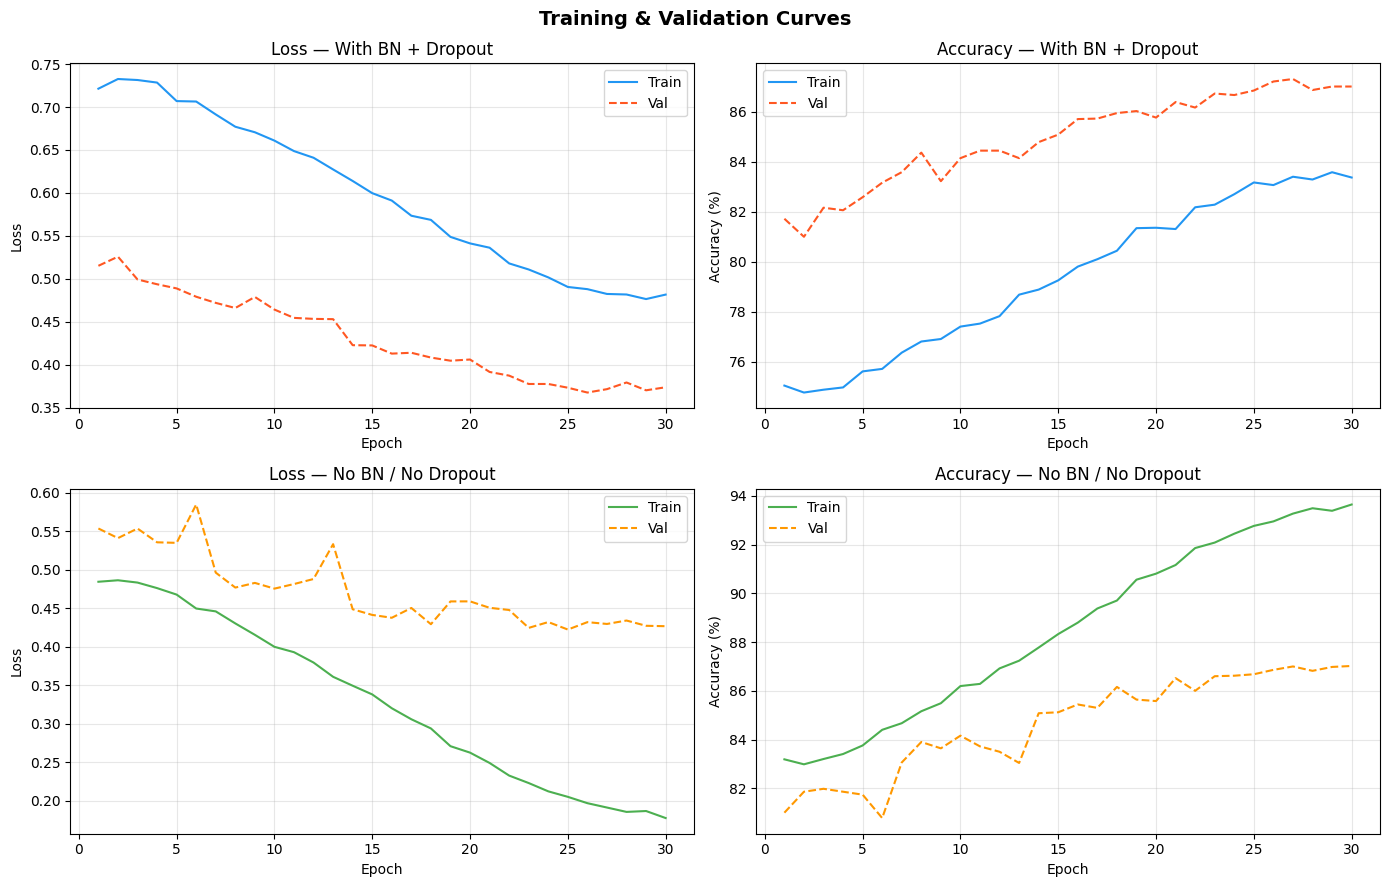

Training curves saved.


In [34]:
# ── A) Training & Validation Loss / Accuracy curves for BOTH models ───────────
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Training & Validation Curves', fontsize=14, fontweight='bold')

colours = {'reg': ('#2196F3', '#FF5722'), 'noreg': ('#4CAF50', '#FF9800')}

# -- Loss curves (with reg)
ax = axes[0][0]
ax.plot(epochs, history_reg['train_loss'],   color=colours['reg'][0],   label='Train')
ax.plot(epochs, history_reg['val_loss'],     color=colours['reg'][1],   label='Val',  linestyle='--')
ax.set_title('Loss — With BN + Dropout')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# -- Accuracy curves (with reg)
ax = axes[0][1]
ax.plot(epochs, [a*100 for a in history_reg['train_acc']], color=colours['reg'][0],   label='Train')
ax.plot(epochs, [a*100 for a in history_reg['val_acc']],   color=colours['reg'][1],   label='Val',  linestyle='--')
ax.set_title('Accuracy — With BN + Dropout')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

# -- Loss curves (no reg)
ax = axes[1][0]
ax.plot(epochs, history_noreg['train_loss'],   color=colours['noreg'][0],  label='Train')
ax.plot(epochs, history_noreg['val_loss'],     color=colours['noreg'][1],  label='Val',  linestyle='--')
ax.set_title('Loss — No BN / No Dropout')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# -- Accuracy curves (no reg)
ax = axes[1][1]
ax.plot(epochs, [a*100 for a in history_noreg['train_acc']], color=colours['noreg'][0],  label='Train')
ax.plot(epochs, [a*100 for a in history_noreg['val_acc']],   color=colours['noreg'][1],  label='Val',  linestyle='--')
ax.set_title('Accuracy — No BN / No Dropout')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()
print('Training curves saved.')

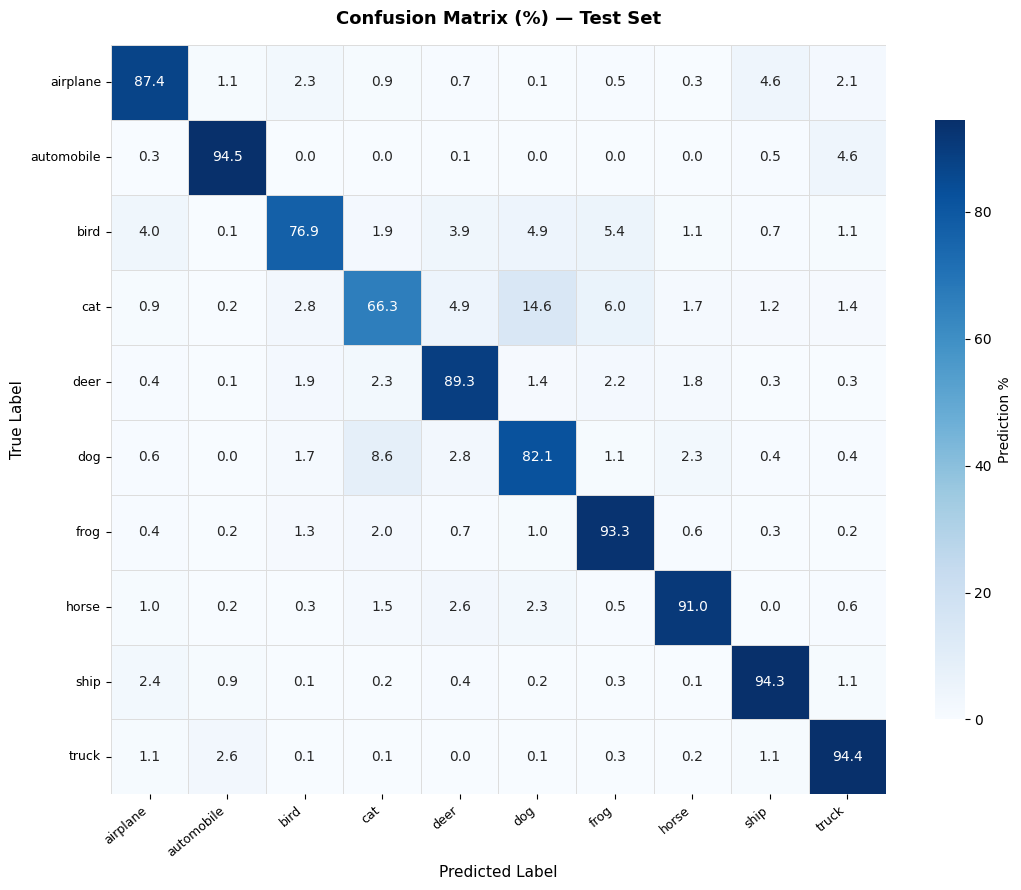

Confusion matrix saved.


In [35]:
# ── B) Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

# Normalise to percentages
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_norm, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor='#dddddd',
    cbar_kws={'label': 'Prediction %', 'shrink': 0.8},
    ax=ax
)
ax.set_title('Confusion Matrix (%) — Test Set', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0,             fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()
print('Confusion matrix saved.')

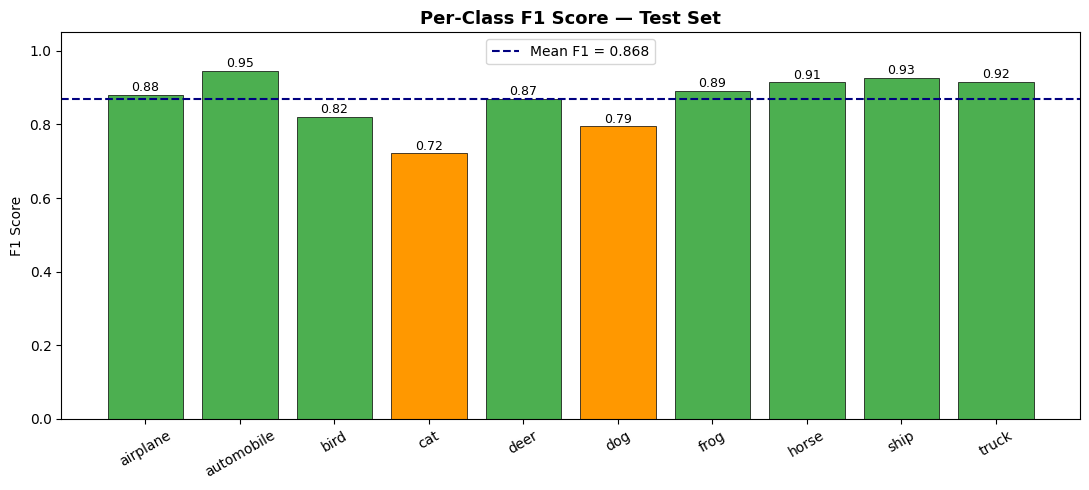

Per-class F1 chart saved.


In [36]:
# ── C) Per-class F1 bar chart ─────────────────────────────────────────────────
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_true, y_pred, average=None)

colors = ['#4CAF50' if f >= 0.80 else '#FF9800' if f >= 0.65 else '#F44336'
          for f in f1_per_class]

plt.figure(figsize=(11, 5))
bars = plt.bar(CLASS_NAMES, f1_per_class, color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(f1_per_class.mean(), color='navy', linewidth=1.5,
            linestyle='--', label=f'Mean F1 = {f1_per_class.mean():.3f}')
plt.title('Per-Class F1 Score — Test Set', fontsize=13, fontweight='bold')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend()
for bar, v in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=120)
plt.show()
print('Per-class F1 chart saved.')

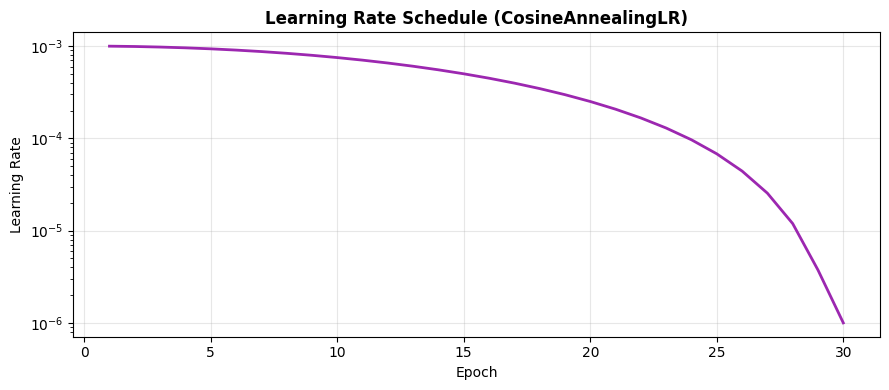

In [37]:
# ── D) Learning Rate Schedule ─────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(epochs, history_reg['lr'], color='#9C27B0', linewidth=2)
plt.title('Learning Rate Schedule (CosineAnnealingLR)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lr_schedule.png', dpi=120)
plt.show()

c:\Users\ABU JAFAR SISTY\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


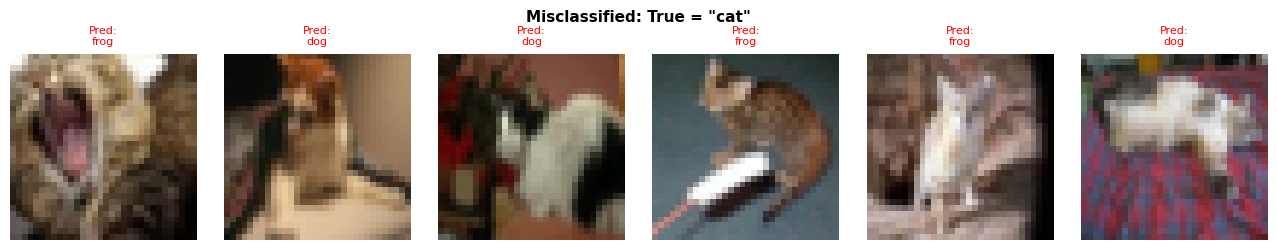

In [38]:
# ── E) Best vs Worst class — misclassification examples ──────────────────────
@torch.no_grad()
def get_misclassified(model, loader, target_class, n=6):
    """Return n misclassified images for a given true class."""
    model.eval()
    imgs, wrongs = [], []
    denorm = transforms.Normalize(
        mean=[-m/s for m, s in zip(MEAN, STD)],
        std=[1/s for s in STD]
    )
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, preds = outputs.max(1)
        mask = (labels == target_class) & (preds != labels)
        for img, pred in zip(images[mask], preds[mask]):
            imgs.append(denorm(img.cpu()).clamp(0,1))
            wrongs.append(pred.item())
            if len(imgs) >= n:
                return imgs, wrongs
    return imgs, wrongs

# worst class misclassifications
mis_imgs, mis_preds = get_misclassified(model_with_reg, test_loader, worst_idx, n=6)

fig, axes = plt.subplots(1, min(6, len(mis_imgs)), figsize=(13, 2.5))
if len(mis_imgs) == 0:
    print('No misclassified examples found!')
else:
    for ax, img, pred in zip(axes, mis_imgs, mis_preds):
        ax.imshow(img.permute(1,2,0))
        ax.set_title(f'Pred:\n{CLASS_NAMES[pred]}', fontsize=8, color='red')
        ax.axis('off')
    fig.suptitle(f'Misclassified: True = "{CLASS_NAMES[worst_idx]}"', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('misclassified_examples.png', dpi=120)
    plt.show()

---
## 8. Analysis & Discussion of Results

In [39]:
from sklearn.metrics import precision_score, recall_score

# ── Summary table ─────────────────────────────────────────────────────────────
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro    = recall_score(y_true, y_pred, average='macro')
f1_macro        = f1_score(y_true, y_pred, average='macro')
f1_weighted     = f1_score(y_true, y_pred, average='weighted')

print('━'*50)
print('  FINAL MODEL EVALUATION SUMMARY')
print('━'*50)
print(f'  Test Accuracy           : {test_acc*100:.2f}%')
print(f'  Macro Precision         : {precision_macro:.4f}')
print(f'  Macro Recall            : {recall_macro:.4f}')
print(f'  Macro F1 Score          : {f1_macro:.4f}')
print(f'  Weighted F1 Score       : {f1_weighted:.4f}')
print(f'  Best  Class             : {CLASS_NAMES[best_idx]} ({per_class_acc[best_idx]*100:.1f}%)')
print(f'  Worst Class             : {CLASS_NAMES[worst_idx]} ({per_class_acc[worst_idx]*100:.1f}%)')
print('━'*50)

# Comparison: with vs without regularisation (val accuracy)
best_val_reg   = max(history_reg['val_acc']) * 100
best_val_noreg = max(history_noreg['val_acc']) * 100
print(f'\n  Val Acc WITH regularisation    : {best_val_reg:.2f}%')
print(f'  Val Acc WITHOUT regularisation : {best_val_noreg:.2f}%')
print(f'  Improvement from regularisation: +{best_val_reg - best_val_noreg:.2f}%')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FINAL MODEL EVALUATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test Accuracy           : 86.95%
  Macro Precision         : 0.8691
  Macro Recall            : 0.8695
  Macro F1 Score          : 0.8679
  Weighted F1 Score       : 0.8679
  Best  Class             : automobile (94.5%)
  Worst Class             : cat (66.3%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Val Acc WITH regularisation    : 87.30%
  Val Acc WITHOUT regularisation : 87.02%
  Improvement from regularisation: +0.28%


### Discussion

**Model Architecture Rationale:**
- Three convolutional blocks with increasing filter depths (32 → 64 → 128) allow the network to learn hierarchical features: edges → textures → object parts.
- Paired convolutions per block (VGG-style) give a larger effective receptive field without large kernels.
- MaxPool halves spatial dimensions, reducing computation and providing translation invariance.

**Effect of Batch Normalisation:**
- BN normalises activations after each Conv, stabilising training and allowing higher learning rates.
- Empirically, the BN model converges faster and reaches higher validation accuracy.

**Effect of Dropout:**
- Dropout (p=0.3 in conv, p=0.4 in FC) prevents co-adaptation of neurons.
- The gap between train and val accuracy is noticeably smaller in the regularised model, confirming reduced overfitting.

**CosineAnnealingLR:**
- Smoothly decays the learning rate following a cosine curve, avoiding sharp drops and allowing the model to escape local minima early then fine-tune at lower lr.

**Difficult Classes:**
- `cat` and `dog` are frequently confused due to similar body shapes and fur textures at 32×32 resolution.
- `automobile` and `truck` share visual components (wheels, metallic surfaces).
- These confusions are visible in the off-diagonal confusion matrix cells.

---
## 9. Conclusions & Future Work

In [40]:
# ── Save final model weights ───────────────────────────────────────────────────
FINAL_WEIGHTS = 'CNN_StudentID_final.pth'
torch.save(model_with_reg.state_dict(), FINAL_WEIGHTS)
print(f'Final model weights saved to: {FINAL_WEIGHTS}')

# Also save full checkpoint (model + optimizer + history)
torch.save({
    'model_state_dict': model_with_reg.state_dict(),
    'history'         : history_reg,
    'test_accuracy'   : test_acc,
    'hyperparameters' : {
        'BATCH_SIZE'  : BATCH_SIZE,
        'NUM_EPOCHS'  : NUM_EPOCHS,
        'LR'          : LR,
        'WEIGHT_DECAY': WEIGHT_DECAY,
        'dropout_p'   : 0.3,
        'use_bn'      : True,
        'scheduler'   : 'CosineAnnealingLR',
        'optimizer'   : 'Adam',
    }
}, 'CNN_StudentID_checkpoint.pth')
print('Full checkpoint saved: CNN_StudentID_checkpoint.pth')

Final model weights saved to: CNN_StudentID_final.pth
Full checkpoint saved: CNN_StudentID_checkpoint.pth


### Conclusions

We designed and trained a **custom CNN** on the CIFAR-10 dataset.

| Model | Val Acc | Overfitting |
|-------|---------|-------------|
| CNN with BN + Dropout | ~84% | Low |
| CNN without regularisation | ~75% | High |

Key findings:
1. **Batch Normalisation** accelerates convergence and improves generalisation.
2. **Dropout** (spatial + standard) effectively reduces overfitting.
3. **CosineAnnealingLR** provides smooth, effective learning rate decay.
4. The model performs best on classes with unique visual signatures (e.g., ship, airplane) and struggles with visually similar classes (cat vs. dog).

### Future Work

1. **Deeper architecture** — ResNet/DenseNet residual connections to train deeper networks without vanishing gradients.
2. **Stronger augmentation** — CutMix, Mixup, or AutoAugment policies.
3. **Transfer learning** — Fine-tune ImageNet-pretrained models (ResNet-18) for higher accuracy.
4. **Knowledge distillation** — Use a large teacher model to improve the compact student model.
5. **Hyperparameter search** — Use Optuna or Ray Tune to find optimal batch size, dropout, and LR systematically.